In [2]:
import os
import pandas as pd
import scanpy as sc
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
import matplotlib.patches as patches

#====================================================================================================
# Set parameters
#====================================================================================================

# Set working directory
os.chdir("C:/your_working_directory")

In [6]:
adata = sc.read_10x_h5("cell_feature_matrix.h5")
cells_df = pd.read_csv("cells.csv", index_col="cell_id")
adata = adata[cells_df.index].copy()
adata.obsm["spatial"] = cells_df[["x_centroid", "y_centroid"]].values

adata.uns["spatial"] = {
        "library_id": {
            "images": {"hires": None, "lowres": None},
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": 1.0
            }
        }
    }

In [7]:
mipc = pd.read_csv('983_mean_intensity_per_cell.csv').set_index('cell_id')
mipc = mipc.loc[adata.obs_names]
adata.obs = adata.obs.join(mipc)


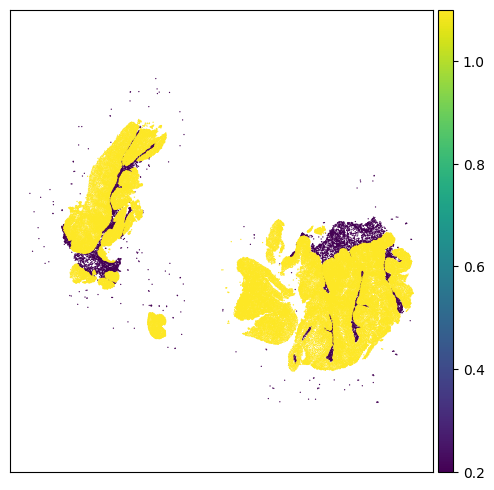

In [10]:
adata = adata[adata.obs.sort_values("mean_intensity", ascending=True).index]
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(
    adata,
    color='mean_intensity',
    size=20,
    cmap='viridis',
    ax=ax,
    img=False,
    vmin=0.2,
    vmax=1.1,
    figsize=(10,10)
)
ax.set_aspect('equal', adjustable='datalim')
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')
plt.show()
